# GTFS to Public Transit Graphs

This notebook converts a General Transit Feed Specification (GTFS) feed for London into graph representations with city2graph. Starting from the raw zip file, it builds a stop-to-stop travel-time network, measures betweenness centrality, and compares walk-only against walk-plus-transit isochrones.

## 1. Environment Setup and Dependencies

city2graph builds on GeoPandas, Shapely, and NetworkX; contextily supplies the basemaps used in the figures.

In [1]:
# Geospatial data processing
import geopandas as gpd
import networkx as nx
import rustworkx as rx
import pandas as pd

# Mapping and visualization
import contextily as ctx
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

# Network analysis
import osmnx as ox

# Others
from pathlib import Path

# The star of the show: city2graph for transportation network analysis
import city2graph as c2g

## 2. Loading GTFS Data

### What is GTFS?

The General Transit Feed Specification (GTFS) is the de facto standard for publishing public transport schedules and geography. A feed is a set of linked tables:

- `routes`: transit lines (bus routes, train lines, and so on)
- `stops`: locations where passengers board and alight
- `trips`: individual vehicle journeys along a route
- `stop_times`: scheduled arrival and departure times at each stop
- `calendar`: service patterns (weekdays, weekends, holidays)

`load_gtfs()` reads the zipped feed directly, so no manual unpacking or CSV joining is needed. The example uses a Transport for London feed.

In [2]:
# Load GTFS data into DuckDB (current API)
sample_gtfs_path = Path("./data/itm_london_gtfs.zip")

print("Loading London Transport GTFS data into DuckDB...")
gtfs_con = c2g.load_gtfs(sample_gtfs_path)
print("GTFS database ready.")

Loading London Transport GTFS data into DuckDB...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

GTFS database ready.


In [3]:
# Inspect loaded GTFS tables from DuckDB
tables_df = gtfs_con.execute("SHOW TABLES").df()
table_names = sorted(tables_df["name"].tolist())

print(f"Found {len(table_names)} data tables")
print(", ".join(table_names))

for table in ["stops", "routes", "stop_times"]:
    if table in table_names:
        n = gtfs_con.execute(f"SELECT COUNT(*) AS n FROM {table}").df().loc[0, 'n']
        print(f"Total {table}: {n:,}")

Found 10 data tables
agency, calendar, calendar_dates, feed_info, frequencies, routes, shapes, stop_times, stops, trips
Total stops: 24,745
Total routes: 1,087
Total stop_times: 17,807,603


### The GTFS Data Structure

`load_gtfs()` returns a DuckDB connection with the GTFS tables loaded in memory. For a large feed this keeps things fast: only the rows needed are queried with SQL and converted to pandas or GeoPandas at the last step. The following cells inspect each table in turn.

In [4]:
# Explore GTFS tables available in DuckDB
print("Available GTFS tables:")
for i, table_name in enumerate(table_names, 1):
    num_records = gtfs_con.execute(
        f"SELECT COUNT(*) AS n FROM {table_name}"
    ).df().loc[0, 'n']
    print(f"  {i}. {table_name}: {num_records:,} records")

print("\n" + "=" * 50)
print("GTFS Table Descriptions:")
print("=" * 50)
print("agency         - Transit operators (TfL, etc.)")
print("calendar       - Service patterns (weekdays/weekends)")
print("routes         - Transit lines")
print("stops          - Physical stop locations (with coordinates)")
print("stop_times     - Scheduled arrivals/departures")
print("trips          - Individual vehicle journeys")
print("calendar_dates - Service exceptions (holidays, etc.)")

table_names

Available GTFS tables:
  1. agency: 56 records
  2. calendar: 576 records
  3. calendar_dates: 40,264 records
  4. feed_info: 1 records
  5. frequencies: 61 records
  6. routes: 1,087 records
  7. shapes: 147,172 records
  8. stop_times: 17,807,603 records
  9. stops: 24,745 records
  10. trips: 488,935 records

GTFS Table Descriptions:
agency         - Transit operators (TfL, etc.)
calendar       - Service patterns (weekdays/weekends)
routes         - Transit lines
stops          - Physical stop locations (with coordinates)
stop_times     - Scheduled arrivals/departures
trips          - Individual vehicle journeys
calendar_dates - Service exceptions (holidays, etc.)


['agency',
 'calendar',
 'calendar_dates',
 'feed_info',
 'frequencies',
 'routes',
 'shapes',
 'stop_times',
 'stops',
 'trips']

In [5]:
# Agency information - Who operates the transit services?
print("Transit Agencies:")
print("This table contains information about transportation operators")
gtfs_con.execute("SELECT * FROM agency LIMIT 5").df()

Transit Agencies:
This table contains information about transportation operators


,agency_id,agency_name,agency_url,agency_timezone,agency_lang,agency_phone,agency_noc
0,OP11949,Golden Tours,https://www.traveline.info,Europe/London,EN,None,GTSL
1,OP14145,Quality Line,https://www.traveline.info,Europe/London,EN,None,QULN
2,OP14161,London Underground (TfL),https://www.traveline.info,Europe/London,EN,None,LULD
3,OP14162,NATIONAL EXPRESS OPERAT,https://www.traveline.info,Europe/London,EN,None,SS
4,OP14163,London Docklands Light Railway - TfL,https://www.traveline.info,Europe/London,EN,None,LDLR


In [6]:
gtfs_con.execute("SELECT * FROM calendar LIMIT 5").df()

,service_id,monday,tuesday,wednesday,thursday,friday,saturday,sunday,start_date,end_date
0,1,1,1,1,1,1,1,0,20250530,20260228
1,2,1,1,1,1,1,0,0,20250530,20260228
2,3,0,0,0,0,0,1,0,20250530,20260228
3,19,0,0,0,0,0,0,1,20250530,20260228
4,21,1,1,1,1,1,0,0,20250530,20260228


In [7]:
gtfs_con.execute("SELECT * FROM calendar_dates LIMIT 5").df()

,service_id,date,exception_type
0,20458,20250903,1
1,31969,20251001,2
2,31438,20250711,2
3,20583,20251105,1
4,33097,20251201,1


In [8]:
gtfs_con.execute("SELECT * FROM routes LIMIT 5").df()

,route_id,agency_id,route_short_name,route_long_name,route_type
0,58,OP5050,025,None,200
1,89,OP5050,444,None,200
2,100,OP5050,007,None,200
3,116,OP5050,022,None,200
4,289,OP53,372,None,3


In [9]:
# Stops - The spatial foundation of transit networks
stops_df = gtfs_con.execute(
    """
    SELECT * EXCLUDE (geometry), ST_AsText(geometry) AS geometry_wkt
    FROM stops
    LIMIT 5
    """
).df()
stops_preview = gpd.GeoDataFrame(
    stops_df.drop(columns=["geometry_wkt"]),
    geometry=gpd.GeoSeries.from_wkt(stops_df["geometry_wkt"]),
    crs="EPSG:4326",
)

print("Transit Stops (with Spatial Coordinates):")
print("Notice how city2graph stores stop geometry in DuckDB and we can convert to GeoPandas")
print(f"Coordinate Reference System: {stops_preview.crs}")
print(f"Geometry type: {stops_preview.geometry.geom_type.iloc[0]}")

stops_preview.head()

Transit Stops (with Spatial Coordinates):
Notice how city2graph stores stop geometry in DuckDB and we can convert to GeoPandas
Coordinate Reference System: EPSG:4326
Geometry type: Point


,stop_id,stop_code,stop_name,stop_lat,stop_lon,wheelchair_boarding,location_type,parent_station,platform_code,geometry
0,490014597S,48536,White Hart Ln Grt Cambridge Rd,51.6049,-0.08595,0,0,None,None,POINT (-0.08595 51.6049)
1,490007372S,74106,Granville Place,51.5965,-0.38728,0,0,None,None,POINT (-0.38728 51.5965)
2,490013521E,52358,The Ravensbury,51.39799,-0.15787,0,0,None,None,POINT (-0.15787 51.39799)
3,240G006160A,NaN,Bus Station,51.27127,0.1933035,0,1,None,None,POINT (0.1933 51.27127)
4,490007476V,56036,Palmers Green / Green Lanes,51.61252,-0.1071,0,0,None,None,POINT (-0.1071 51.61252)


In [10]:
gtfs_con.execute("SELECT * FROM stop_times LIMIT 5").df()

,trip_id,arrival_time,departure_time,stop_id,stop_sequence,stop_headsign,pickup_type,drop_off_type,shape_dist_traveled,timepoint
0,VJ000015f02fdb2ffc0444ac5453798bd8befdca76,05:05:00,05:05:00,490006587C,1,None,0,0,None,0
1,VJ000015f02fdb2ffc0444ac5453798bd8befdca76,05:05:00,05:05:00,490009222A,0,None,0,1,None,0
2,VJ000015f02fdb2ffc0444ac5453798bd8befdca76,05:06:00,05:06:00,490006588R,2,None,0,0,None,0
3,VJ000015f02fdb2ffc0444ac5453798bd8befdca76,05:06:00,05:06:00,490009169S,3,None,0,0,None,0
4,VJ000015f02fdb2ffc0444ac5453798bd8befdca76,05:07:00,05:07:00,490004650S,5,None,0,0,None,0


In [11]:
gtfs_con.execute("SELECT * FROM trips LIMIT 5").df()

,route_id,service_id,trip_id,trip_headsign,direction_id,block_id,shape_id,wheelchair_accessible,vehicle_journey_code
0,58,32443,VJ0b7453c953d79096488dd30c8d67da29644842ed,"Brighton - Victoria, London",1,None,None,0,VJ99
1,58,32443,VJ0873eade6dfa11f222109beac2b7504007554ccd,"Belgravia, Victoria - Brighton",0,None,None,0,VJ109
2,58,32443,VJ01dbdf44f6d74ff8027d089fb3db5ae022559673,"Worthing - Victoria, London",1,None,None,0,VJ57
3,58,32445,VJ1218298147f26d820d17ed4344a4dc9dc5f24cb6,"Brighton - Victoria, London",1,None,None,0,VJ29
4,58,32444,VJ18b4d838cbdac9a9ab9de1d2f0ca0426719ba0a8,"Belgravia, Victoria - Brighton",0,None,None,0,VJ142


Visualizing London's Transit Stops


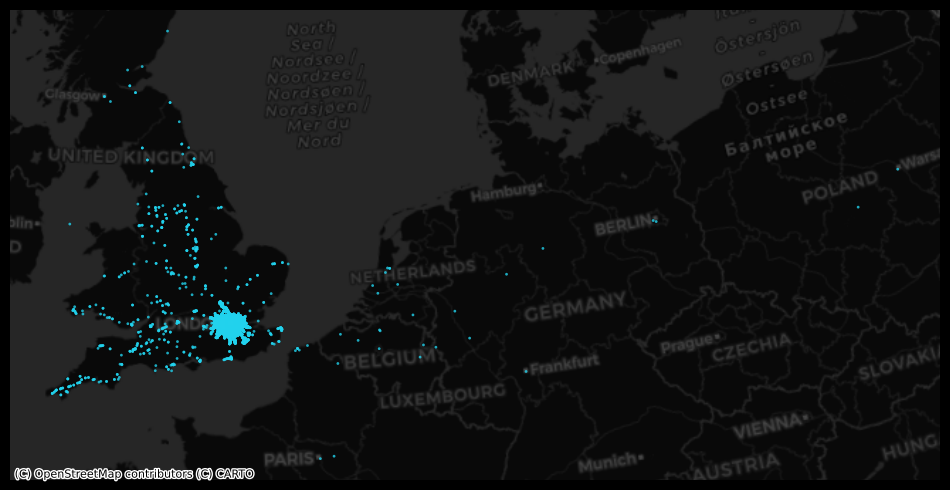

In [12]:
# Build a full stops GeoDataFrame from DuckDB for quick map preview
stops_all_df = gtfs_con.execute(
    """
    SELECT * EXCLUDE (geometry), ST_AsText(geometry) AS geometry_wkt
    FROM stops
    """
).df()
stops_gdf = gpd.GeoDataFrame(
    stops_all_df.drop(columns=["geometry_wkt"]),
    geometry=gpd.GeoSeries.from_wkt(stops_all_df["geometry_wkt"]),
    crs="EPSG:4326",
)

# Reproject to British National Grid for accurate map display
stops_gdf_bng = stops_gdf.to_crs(epsg=27700)

print("Visualizing London's Transit Stops")
ax = c2g.plot_graph(nodes=stops_gdf_bng)
ctx.add_basemap(ax, crs=stops_gdf_bng.crs, source=ctx.providers.CartoDB.DarkMatter)
plt.show()

## 3. Creating Transit Graphs

A feed describes thousands of individual trips, but network analysis needs the connections they imply. The next step aggregates trips into a graph of stops.

`travel_summary_graph()` summarises trips between consecutive stops over a chosen time window, returning edges with the average travel time in seconds and the service frequency. The result is an ordinary pair of node and edge GeoDataFrames, so it can be analysed directly or converted to NetworkX or PyTorch Geometric.

In [13]:
# Transform GTFS schedules into a travel network graph
travel_summary_nodes, travel_summary_edges = c2g.travel_summary_graph(
    gtfs_con,
    calendar_start="20250601",  # Analyze services for June 1, 2025
    calendar_end="20250601",     # Single day analysis for demonstration
)

travel_summary_nodes = travel_summary_nodes.to_crs(epsg=27700)
travel_summary_edges = travel_summary_edges.to_crs(epsg=27700)

print("Created graph with:")
print(f"   • {len(travel_summary_nodes):,} nodes (stops with connections)")
print(f"   • {len(travel_summary_edges):,} edges (stop-to-stop connections)")
print("   • Each edge contains travel time (seconds) and frequency data")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Created graph with:
   • 24,745 nodes (stops with connections)
   • 26,449 edges (stop-to-stop connections)
   • Each edge contains travel time (seconds) and frequency data


In [14]:
travel_summary_nodes.head()

,stop_code,stop_name,stop_lat,stop_lon,wheelchair_boarding,location_type,parent_station,platform_code,geometry
stop_id,,,,,,,,,
01000053216,bstgjpt,Bus Station,51.45906,-2.59298,0,0,010G0005,8,POINT (358898.332 173509.501)
01000053218,bstgjmw,Bus Station,51.45901,-2.59314,0,0,010G0005,6,POINT (358887.171 173504.03)
01000053221,bstgjgm,Bus Station,51.45895,-2.59334,0,0,010G0005,3,POINT (358873.221 173497.47)
0100BRP90233,bstdmgp,Triangle West,51.45652,-2.60802,0,0,NaN,NaN,POINT (357851.066 173235.586)
0100BRP90237,bstdmwa,Queen's Road,51.45651,-2.60658,0,0,NaN,NaN,POINT (357951.108 173233.644)


In [15]:
# Examine the edges (connections) in our travel network
print("Network Edges (Transit Connections):")
print("Each row represents a direct connection between two stops")
print("\nKey metrics city2graph calculated:")
print("   • travel_time_sec: Average time to travel between stops (seconds)")
print("   • frequency: Number of services per day on this connection")
print("   • geometry: LineString for mapping and spatial analysis")

print(f"\nPerformance insight:")
print(f"   Fastest connection: {travel_summary_edges['travel_time_sec'].min():.0f} seconds")
print(f"   Busiest connection: {travel_summary_edges['frequency'].max():.0f} services/day")
print(f"   Average travel time: {travel_summary_edges['travel_time_sec'].mean():.0f} seconds")

travel_summary_edges.head()

Network Edges (Transit Connections):
Each row represents a direct connection between two stops

Key metrics city2graph calculated:
   • travel_time_sec: Average time to travel between stops (seconds)
   • frequency: Number of services per day on this connection
   • geometry: LineString for mapping and spatial analysis

Performance insight:
   Fastest connection: 1 seconds
   Busiest connection: 1066 services/day
   Average travel time: 219 seconds


frequency  \
from_stop_id to_stop_id                
01000053216  0170SGP90689        179   
             0190NSZ01231         14   
             035059860001         28   
             1100DEA57098         12   
             360000174            46   

                                                                    geometry  \
from_stop_id to_stop_id                                                        
01000053216  0170SGP90689  LINESTRING (358898.332 173509.501, 362270.014 ...   
             0190NSZ01231  LINESTRING (358898.332 173509.501, 336803.818 ...   
             035059860001  LINESTRING (358898.332 173509.501, 471026.138 ...   
             1100DEA57098  LINESTRING (358898.332 173509.501, 292592.045 ...   
             360000174     LINESTRING (358898.332 173509.501, 325332.697 ...   

                           travel_time_sec  
from_stop_id to_stop_id                     
01000053216  0170SGP90689        821.22905  
             0190NSZ01231       3000.00000  
             035059860001       5625.00000  
             1100DEA57098       6450.00000  
             360000174          3750.00000

In [16]:
# Examine the edges (connections) in our travel network
print("Network Edges (Transit Connections):")
print("Each row represents a direct connection between two stops")
print("\nKey metrics city2graph calculated:")
print("   • travel_time_sec: Average time to travel between stops (seconds)")
print("   • frequency: Number of services per day on this connection")
print("   • geometry: LineString for mapping and spatial analysis")

print(f"\nPerformance insight:")
print(f"   Fastest connection: {travel_summary_edges['travel_time_sec'].min():.0f} seconds")
print(f"   Busiest connection: {travel_summary_edges['frequency'].max():.0f} services/day")
print(f"   Average travel time: {travel_summary_edges['travel_time_sec'].mean():.0f} seconds")

travel_summary_edges.head()

Network Edges (Transit Connections):
Each row represents a direct connection between two stops

Key metrics city2graph calculated:
   • travel_time_sec: Average time to travel between stops (seconds)
   • frequency: Number of services per day on this connection
   • geometry: LineString for mapping and spatial analysis

Performance insight:
   Fastest connection: 1 seconds
   Busiest connection: 1066 services/day
   Average travel time: 219 seconds


frequency  \
from_stop_id to_stop_id                
01000053216  0170SGP90689        179   
             0190NSZ01231         14   
             035059860001         28   
             1100DEA57098         12   
             360000174            46   

                                                                    geometry  \
from_stop_id to_stop_id                                                        
01000053216  0170SGP90689  LINESTRING (358898.332 173509.501, 362270.014 ...   
             0190NSZ01231  LINESTRING (358898.332 173509.501, 336803.818 ...   
             035059860001  LINESTRING (358898.332 173509.501, 471026.138 ...   
             1100DEA57098  LINESTRING (358898.332 173509.501, 292592.045 ...   
             360000174     LINESTRING (358898.332 173509.501, 325332.697 ...   

                           travel_time_sec  
from_stop_id to_stop_id                     
01000053216  0170SGP90689        821.22905  
             0190NSZ01231       3000.00000  
             035059860001       5625.00000  
             1100DEA57098       6450.00000  
             360000174          3750.00000

Next we clip the transit network to the Greater London administrative boundary and continue the network analysis on this London-wide graph.

In [17]:
# Get Greater London boundary using city2graph
london_boundary = c2g.get_boundaries("Greater London, UK").to_crs(epsg=27700)

# Ensure projected CRS for spatial operations
travel_summary_nodes = travel_summary_nodes.to_crs(epsg=27700)
travel_summary_edges = travel_summary_edges.to_crs(epsg=27700)

# Clip graph to Greater London extent
print("Clipping nodes and edges to Greater London boundary...")
travel_summary_nodes, travel_summary_edges = c2g.clip_graph(
    (travel_summary_nodes, travel_summary_edges),
    london_boundary,
    keep_outer_neighbors=False,
 )

print("Boundary clipping complete:")
print(f"   Nodes within London: {len(travel_summary_nodes):,}")
print(f"   Edges within London: {len(travel_summary_edges):,}")

Clipping nodes and edges to Greater London boundary...
Boundary clipping complete:
   Nodes within London: 19,233
   Edges within London: 23,133


In [18]:
# Quick check of London-wide network
print("Greater London network summary")
print(f"Nodes: {len(travel_summary_nodes):,}")
print(f"Edges: {len(travel_summary_edges):,}")
travel_summary_nodes.head()

Greater London network summary
Nodes: 19,233
Edges: 23,133


,stop_code,stop_name,stop_lat,stop_lon,wheelchair_boarding,location_type,parent_station,platform_code,geometry
stop_id,,,,,,,,,
210021803340,hrtajatj,Mount Vernon Hospital,51.61460025309353,-0.450657771262085,0,0,NaN,NaN,POINT (507371.001 191778)
490000002A,57685,Acton Town,51.50273,-0.28101,0,0,NaN,NaN,POINT (519408.799 179599.927)
490000002B,50980,Acton Town,51.50402,-0.27986,0,0,NaN,NaN,POINT (519485.242 179745.257)
490000003B,47908,St Botolph Street,51.51495,-0.07514,0,0,NaN,NaN,POINT (533661.004 181314.47)
490000003R,58621,Aldgate,51.51408,-0.07493,0,0,NaN,NaN,POINT (533678.12 181218.107)


`plot_graph()` gives an overview of the clipped network.

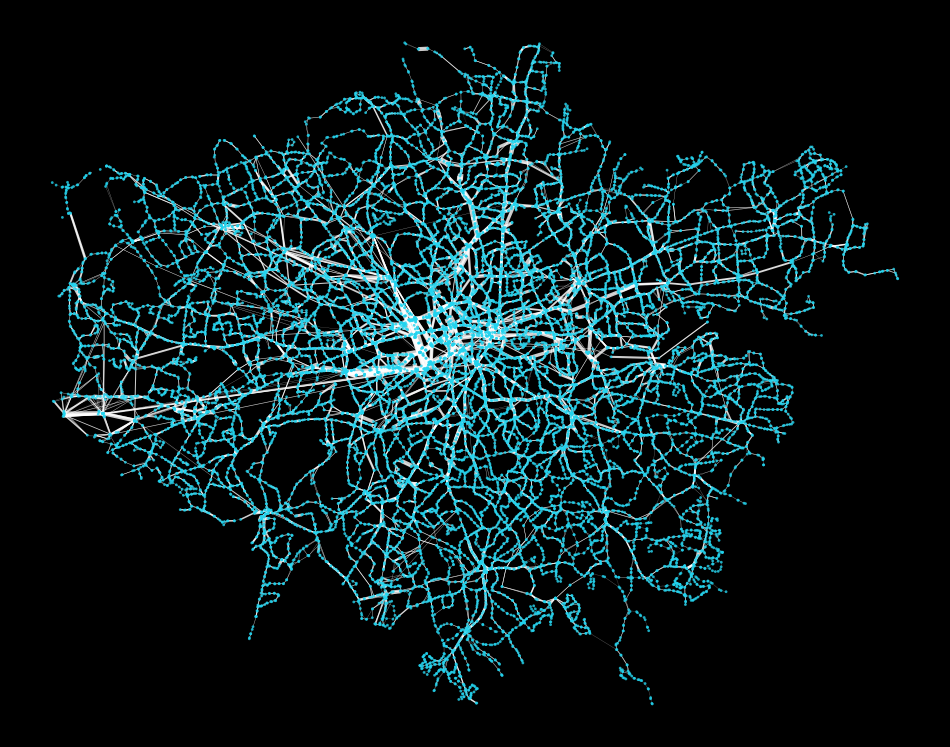

In [19]:
# Plot the network with dual encoding (color + width) using city2graph
c2g.plot_graph(
    nodes=travel_summary_nodes,
    edges=travel_summary_edges,
    edge_color='travel_time_sec',
    edge_linewidth=travel_summary_edges['frequency'] / 250,
    edge_alpha=0.8,
    )
plt.show()

## 4. Network Centrality Analysis

Betweenness centrality identifies the stops that sit on many shortest paths through the network. In the plot below, node colour encodes centrality and edge width encodes service frequency.

NetworkX is not the fastest option for computing centralities on a network of this size. city2graph provides conversion to rustworkx, which computes the same measures considerably faster.

In [20]:
travel_summary_graph = c2g.gdf_to_nx(
    travel_summary_nodes,
    travel_summary_edges,
)

travel_rx_graph = c2g.nx_to_rx(travel_summary_graph)

betweenness_centrality = rx.betweenness_centrality(travel_rx_graph)

# Set the betweenness centrality as a node attribute
nx.set_node_attributes(
    travel_summary_graph,
    betweenness_centrality, 
    "betweenness_centrality"
    )

travel_nodes, travel_edges = c2g.nx_to_gdf(travel_summary_graph)

Removed 3 invalid geometries


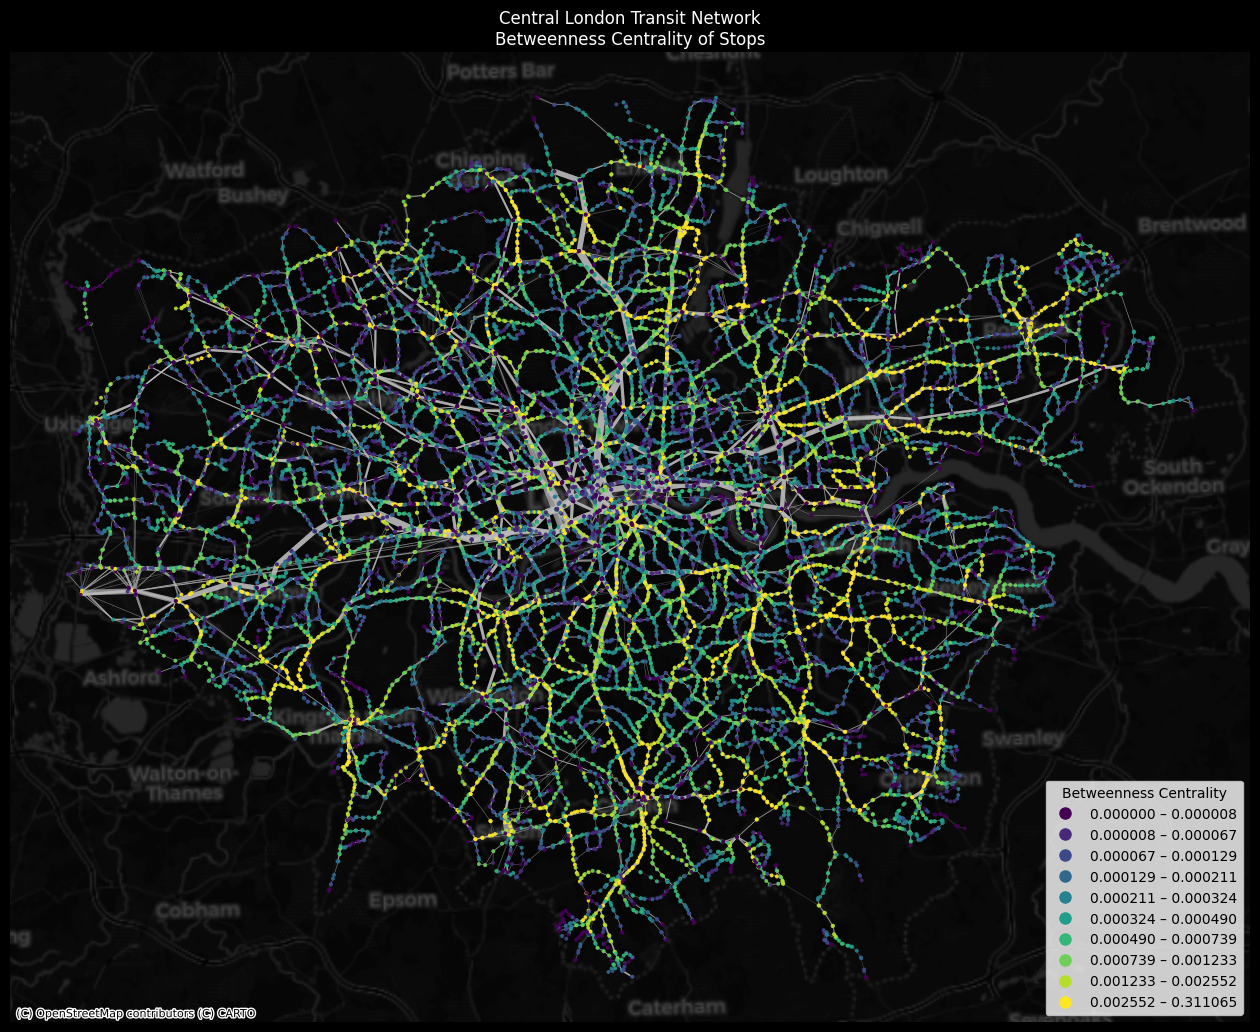

In [21]:
# Calculate quantiles for node size to handle skew in centrality values
# Drop duplicate bin edges to avoid qcut errors when many nodes share the same centrality
centrality_bins = pd.qcut(
    travel_nodes['betweenness_centrality'],
    q=10,
    labels=False,
    duplicates="drop"
)

travel_nodes['centrality_quantile'] = centrality_bins.fillna(0).astype(int) + 1
travel_nodes['node_size_visual'] = travel_nodes['centrality_quantile'] * 15

fig, ax = plt.subplots(figsize=(16, 16))

# Use city2graph to plot the network structure
# Node color represents centrality (skews handled by quantiles)
# Edge width represents frequency
c2g.plot_graph(
    nodes=travel_nodes,
    edges=travel_edges,
    markersize=8,
    node_color='centrality_quantile',
    node_alpha=0.9,
    edge_color='#bbbbbb',
    edge_linewidth=travel_edges['frequency'] / 200,
    edge_alpha=0.7,
    figsize=(16, 16),
    title="Central London Transit Network\nBetweenness Centrality of Stops",
    legend=False,  # remove colorbar
    ax=ax
)

# Add legend for betweenness centrality ranges
cmap = plt.cm.viridis
norm = plt.Normalize(
    vmin=travel_nodes['centrality_quantile'].min(),
    vmax=travel_nodes['centrality_quantile'].max()
)

quantile_ranges = (
    travel_nodes
    .groupby('centrality_quantile')['betweenness_centrality']
    .agg(['min', 'max'])
    .reset_index()
)

handles = [
    mlines.Line2D(
        [],
        [],
        color=cmap(norm(row['centrality_quantile'])),
        marker='o',
        linestyle='',
        markersize=8,
        label=f"{row['min']:.6f} – {row['max']:.6f}"
    )
    for _, row in quantile_ranges.iterrows()
]
ax.legend(handles=handles, title='Betweenness Centrality', loc='lower right')

# Add basemap with a clean, modern style
ctx.add_basemap(ax, crs=travel_nodes.crs, source=ctx.providers.CartoDB.DarkMatter)

plt.show()


The stops with the highest betweenness centrality tend to lie along the main corridors of the network.

To look at local patterns, `filter_graph_by_distance` restricts the graph to nodes within a 15-minute (900-second) travel time of the centre of London.

In [22]:
# Filter graph to show network within 15 minutes from central London
center_point = london_boundary.geometry.to_crs(27700).iloc[0].centroid

filtered_travel_summary_graph = c2g.filter_graph_by_distance(
    travel_summary_graph,
    center_point=center_point,
    threshold=900,  # 900 seconds (~15 minutes travel time)
    edge_attr="travel_time_sec"  # Filter by travel time, not physical distance
)

In [23]:
filtered_travel_rx_graph = c2g.nx_to_rx(filtered_travel_summary_graph)

betweenness_centrality_filtered = rx.betweenness_centrality(filtered_travel_rx_graph)

# Set the betweenness centrality as a node attribute
nx.set_node_attributes(
    filtered_travel_summary_graph,
    betweenness_centrality_filtered, 
    "betweenness_centrality"
    )

In [24]:
filtered_travel_nodes, filtered_travel_edges = c2g.nx_to_gdf(
    filtered_travel_summary_graph
    )

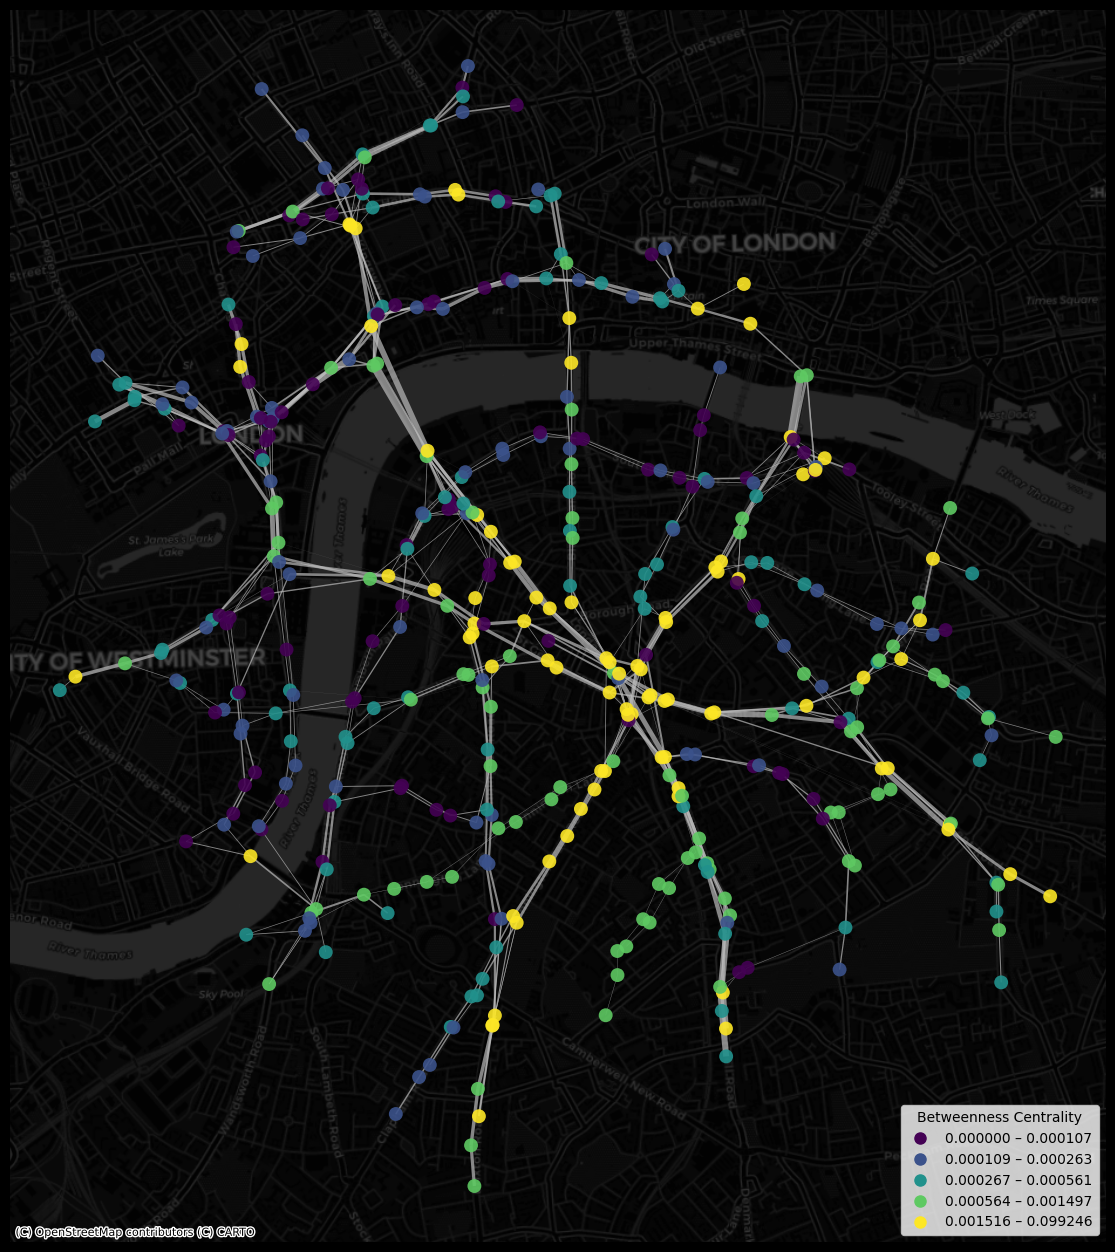

In [25]:
# Calculate quantiles for node size to handle skew in centrality values
# We bin the data into 5 quantiles and scale the size for visibility
filtered_travel_nodes['centrality_quantile'] = pd.qcut(
    filtered_travel_nodes['betweenness_centrality'], 
    q=5, 
    labels=False
) + 1
filtered_travel_nodes['node_size_visual'] = filtered_travel_nodes['centrality_quantile'] * 15

fig, ax = plt.subplots(figsize=(16, 16))

# Use city2graph to plot the network structure
# Node size represents centrality (skews handled by quantiles)
# Edge width represents frequency
c2g.plot_graph(
    nodes=filtered_travel_nodes,
    edges=filtered_travel_edges,
    node_color='centrality_quantile',
    markersize=100,
    node_alpha=0.9,
    edge_color='#bbbbbb',
    edge_linewidth=filtered_travel_edges['frequency'] / 200,
    edge_alpha=0.7,
    ax=ax
)

# Add basemap with a clean, modern style
ctx.add_basemap(ax, crs=filtered_travel_nodes.crs, source=ctx.providers.CartoDB.DarkMatter)

# Add legend for betweenness centrality ranges
cmap = plt.cm.viridis
norm = plt.Normalize(
    vmin=filtered_travel_nodes['centrality_quantile'].min(),
    vmax=filtered_travel_nodes['centrality_quantile'].max()
)

quantile_ranges = (
    filtered_travel_nodes
    .groupby('centrality_quantile')['betweenness_centrality']
    .agg(['min', 'max'])
    .reset_index()
)

handles = [
    mlines.Line2D(
        [],
        [],
        color=cmap(norm(row['centrality_quantile'])),
        marker='o',
        linestyle='',
        markersize=8,
        label=f"{row['min']:.6f} – {row['max']:.6f}"
    )
    for _, row in quantile_ranges.iterrows()
]
ax.legend(handles=handles, title='Betweenness Centrality', loc='lower right')

plt.show()


## 5. Accessibility Analysis with Isochrones

An isochrone is the area reachable from an origin within a given travel time. Comparing isochrones across modes shows how much reach transit adds over walking alone, which makes them a standard tool for accessibility and equity analysis.

`create_isochrone()` builds travel-time relationships from the network edges, finds the nodes reachable within the threshold, and returns a boundary polygon (concave hull, alpha shape, convex hull, or buffer). It works on both homogeneous street networks and heterogeneous walk-plus-transit graphs. This section compares two scenarios from the same origin: walk-only and walk plus transit.

### Walk-Only Baseline

The walk-only baseline uses a walking network fetched for a central London analysis polygon. Restricting the extent keeps the OSM query tractable and gives a direct comparison for the walk-plus-transit scenario.

In [ ]:
# Keep walking-network download limited for performance
analysis_radius_m = 10_000  # 10 km radius around Piccadilly Circus

# Piccadilly Circus (WGS84 input coordinate)
piccadilly_circus_lon, piccadilly_circus_lat = -0.1337, 51.5101
piccadilly_circus_point = gpd.GeoSeries.from_xy(
    [piccadilly_circus_lon],
    [piccadilly_circus_lat],
    crs="EPSG:4326",
).to_crs(epsg=27700).iloc[0]

analysis_area = gpd.GeoDataFrame(
    {"name": ["Piccadilly Circus 10km"]},
    geometry=[piccadilly_circus_point.buffer(analysis_radius_m)],
    crs="EPSG:27700",
)
analysis_poly_wgs84 = analysis_area.to_crs(epsg=4326).geometry.iloc[0]

# Configure OSMnx for reliable downloads
ox.settings.use_cache = True
ox.settings.cache_folder = "./cache/osmnx"
ox.settings.requests_timeout = 180

print("Fetching Central London walk network from OSM...")
print(f"Query polygon area: {analysis_area.geometry.iloc[0].area / 1e6:.1f} km^2")

street_graph = ox.graph_from_polygon(
    analysis_poly_wgs84,
    network_type="walk",
    simplify=True,
    retain_all=True,
    truncate_by_edge=True,
)

if street_graph.number_of_nodes() == 0 or street_graph.number_of_edges() == 0:
    raise RuntimeError(
        "OSM download returned an empty graph. "
        "Try a larger area or check connectivity/API availability."
    )

print(
    f"OSM network downloaded successfully: "
    f"{street_graph.number_of_nodes():,} nodes, {street_graph.number_of_edges():,} edges"
)

# Convert to GeoDataFrames and reproject to British National Grid
street_nodes, street_edges = c2g.nx_to_gdf(street_graph)
street_nodes = street_nodes.to_crs(epsg=27700)
street_edges = street_edges.to_crs(epsg=27700)

# Snap isochrone center to the nearest street node around Piccadilly Circus
nearest_node_idx = street_nodes.geometry.distance(piccadilly_circus_point).idxmin()
center_point = street_nodes.loc[nearest_node_idx, "geometry"]
snap_distance_m = piccadilly_circus_point.distance(center_point)

# Compute walking travel time (seconds) assuming 4.5 km/h = 4500 m/h
street_edges["length"] = street_edges.geometry.length
street_edges["travel_time_sec"] = street_edges["length"] / 4500 * 3600

print(f"Isochrone origin snapped to nearest street node ({snap_distance_m:.1f} m from Piccadilly Circus)")
print(f"Street nodes (limited area): {len(street_nodes):,}")
print(f"Street edges (limited area): {len(street_edges):,}")
display(street_edges.head())

Fetching Central London street network from OSM (walk network)...
Query polygon area: 313.7 km^2
OSM download attempt 1/3


Fetching Central London street network from OSM (walk network)...
Query polygon area: 313.7 km^2
OSM download attempt 1/3
OSM network downloaded successfully: 173,345 nodes, 440,544 edges
Isochrone origin snapped to nearest street node (9.0 m from Piccadilly Circus)
Street nodes (limited area): 173,345
Street edges (limited area): 440,544


osmid      access       highway maxspeed  \
78112 25508583    0  129375498  permissive  unclassified   20 mph   
      25508584    0  129375498  permissive  unclassified   20 mph   
                  1    4257258  permissive   residential   20 mph   
99884 12378884761 0    4082681         NaN       footway      NaN   
      4544836450  0    5090291         NaN       footway      NaN   

                                  name  oneway reversed      length  \
78112 25508583    0       Outer Circle   False    False   19.399136   
      25508584    0       Outer Circle   False     True   63.718133   
                  1  Cambridge Terrace   False    False  102.053589   
99884 12378884761 0                NaN   False    False  173.282760   
      4544836450  0                NaN   False    False  308.182017   

                                                              geometry bridge  \
78112 25508583    0  LINESTRING (528725 182525.235, 528726.116 1825...    NaN   
      25508584    0  LINESTRING (528725 182525.235, 528723.33 18258...    NaN   
                  1  LINESTRING (528725 182525.235, 528744.582 1825...    NaN   
99884 12378884761 0  LINESTRING (528245.101 182222.468, 528259.75 1...    NaN   
      4544836450  0  LINESTRING (528245.101 182222.468, 528275.674 ...    NaN   

                    lanes  ref service junction tunnel width est_width area  \
78112 25508583    0   NaN  NaN     NaN      NaN    NaN   NaN       NaN  NaN   
      25508584    0   NaN  NaN     NaN      NaN    NaN   NaN       NaN  NaN   
                  1   NaN  NaN     NaN      NaN    NaN   NaN       NaN  NaN   
99884 12378884761 0   NaN  NaN     NaN      NaN    NaN   NaN       NaN  NaN   
      4544836450  0   NaN  NaN     NaN      NaN    NaN   NaN       NaN  NaN   

                     travel_time_sec  
78112 25508583    0        15.519308  
      25508584    0        50.974506  
                  1        81.642871  
99884 12378884761 0       138.626208  
      4544836450  0       246.545613

In [36]:
walking_labels = ["5 minutes", "10 minutes", "15 minutes"]
walking_threshold_seconds = [300, 600, 900]
# Compute layered walking isochrones in one call
walking_isochrones = c2g.create_isochrone(
    nodes=street_nodes,
    edges=street_edges,
    center_point=center_point,
    threshold=walking_threshold_seconds,
    edge_attr="travel_time_sec",
    method="concave_hull_knn",
    k=50
 )

walking_isochrones["label"] = walking_labels

for _, row in walking_isochrones.iterrows():
    area_km2 = row.geometry.area / 1e6
    print(f"{row['label']:12} -> {area_km2:6.2f} km^2 reachable area")


5 minutes    ->   0.28 km^2 reachable area
10 minutes   ->   1.13 km^2 reachable area
15 minutes   ->   2.66 km^2 reachable area


/var/folders/_n/l2f9tkgn3g17dj7hnsjprssc0000gn/T/ipykernel_92928/2395002001.py:29: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc="upper right", framealpha=0.9)


/var/folders/_n/l2f9tkgn3g17dj7hnsjprssc0000gn/T/ipykernel_92928/2395002001.py:29: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc="upper right", framealpha=0.9)


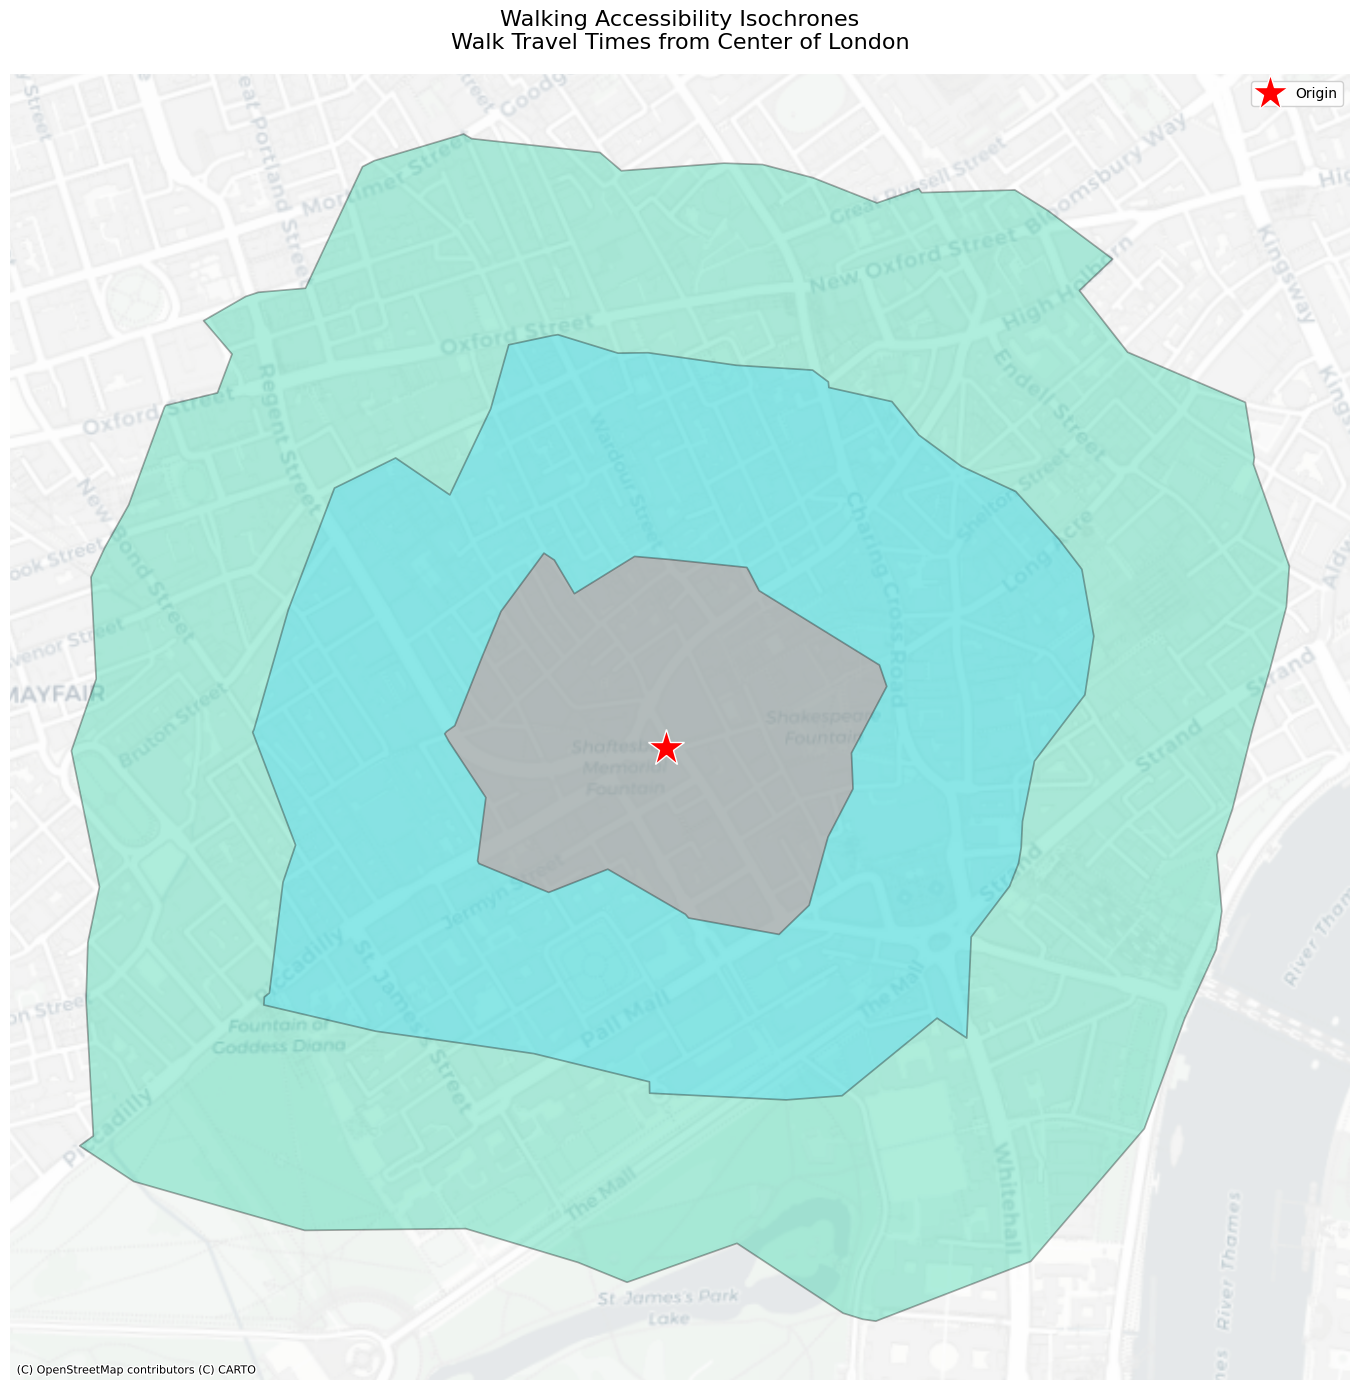

In [37]:
fig, ax = plt.subplots(figsize=(16, 14))

color_by_label = {
    "5 minutes": "#ff6b6b",
    "10 minutes": "#48dbfb",
    "15 minutes": "#1dd1a1",
}

# Plot larger thresholds first for layering
for _, row in walking_isochrones.sort_values("threshold", ascending=False).iterrows():
    row_gdf = gpd.GeoDataFrame([row], geometry="geometry", crs=walking_isochrones.crs)
    row_gdf.plot(
        ax=ax,
        alpha=0.35,
        color=color_by_label.get(row["label"], "#1dd1a1"),
        edgecolor="#111111",
        linewidth=1.25,
        label=row["label"],
        zorder=2,
    )

# Origin marker
ax.plot(center_point.x, center_point.y, "r*", markersize=28, markeredgecolor="white", label="Origin", zorder=4)

# Basemap for context
ctx.add_basemap(ax, crs=street_nodes.crs, source=ctx.providers.CartoDB.Positron, alpha=0.6)

ax.set_title("Walking Accessibility Isochrones\nWalk Travel Times from Center of London", fontsize=16, color="black", pad=18)
ax.legend(loc="upper right", framealpha=0.9)
ax.axis("off")
plt.tight_layout()
plt.show()

### Walk + Transit

With a multimodal graph combining street intersections and bus stops, walk-plus-transit isochrones are computed over `travel_time_sec` across all edge types. The difference from the walk-only baseline is the accessibility gained from transit.

In [38]:
hetero_nodes = {
    "street_intersection": street_nodes,
    "bus_station": travel_summary_nodes,
}

hetero_edges = {
    ("street_intersection", "is_connected_to", "street_intersection"): street_edges,
    ("bus_station", "is_next_to", "bus_station"): travel_summary_edges,
}

In [39]:
_, bridged_edges = c2g.bridge_nodes(hetero_nodes, source_node_types=["bus_station"])

bridged_edges[('bus_station', 'is_nearby', 'street_intersection')]["travel_time_sec"] = bridged_edges[('bus_station', 'is_nearby', 'street_intersection')].geometry.length / 4500 * 3600

hetero_edges.update(bridged_edges)

In [40]:
multimodal_labels = ["5 minutes", "10 minutes", "15 minutes"]
multimodal_threshold_seconds = [300, 600, 900]

# Compute layered multimodal isochrones in one call
multimodal_isochrones = c2g.create_isochrone(
    nodes=hetero_nodes,
    edges=hetero_edges,
    center_point=center_point,
    threshold=multimodal_threshold_seconds,
    edge_attr="travel_time_sec",
    cut_edge_types=[("bus_station", "is_next_to", "bus_station")],  # Only cut walking edges for multimodal isochrone
    method="concave_hull_knn",
    k=50
 )

multimodal_isochrones["label"] = multimodal_labels

for _, row in multimodal_isochrones.iterrows():
    area_km2 = row.geometry.area / 1e6
    print(f"{row['label']:12} -> {area_km2:6.2f} km^2 reachable area")


Removed 3 invalid geometries


Removed 3 invalid geometries


5 minutes    ->   0.38 km^2 reachable area
10 minutes   ->   4.87 km^2 reachable area
15 minutes   ->  25.72 km^2 reachable area


/var/folders/_n/l2f9tkgn3g17dj7hnsjprssc0000gn/T/ipykernel_92928/1743933503.py:29: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc="upper right", framealpha=0.9)


/var/folders/_n/l2f9tkgn3g17dj7hnsjprssc0000gn/T/ipykernel_92928/1743933503.py:29: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc="upper right", framealpha=0.9)


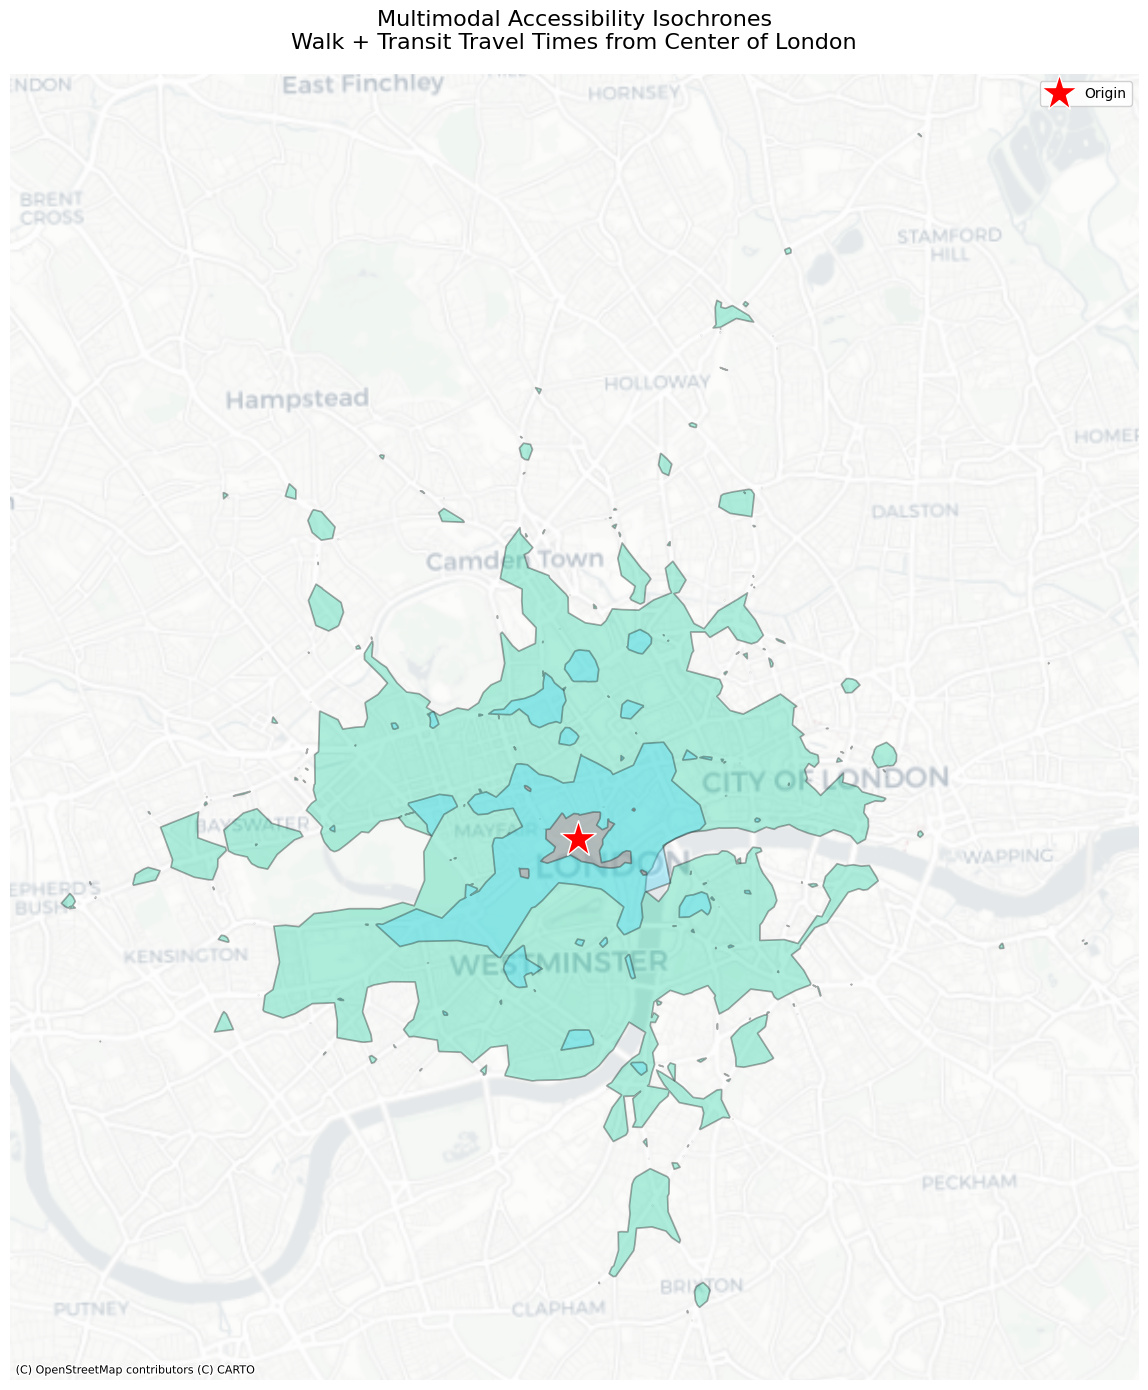

In [41]:
fig, ax = plt.subplots(figsize=(16, 14))

color_by_label = {
    "5 minutes": "#ff6b6b",
    "10 minutes": "#48dbfb",
    "15 minutes": "#1dd1a1",
}

# Plot larger thresholds first for layering
for _, row in multimodal_isochrones.sort_values("threshold", ascending=False).iterrows():
    row_gdf = gpd.GeoDataFrame([row], geometry="geometry", crs=multimodal_isochrones.crs)
    row_gdf.plot(
        ax=ax,
        alpha=0.35,
        color=color_by_label.get(row["label"], "#1dd1a1"),
        edgecolor="#111111",
        linewidth=1.25,
        label=row["label"],
        zorder=2,
    )

# Origin marker
ax.plot(center_point.x, center_point.y, "r*", markersize=28, markeredgecolor="white", label="Origin", zorder=4)

# Basemap for context
ctx.add_basemap(ax, crs=street_nodes.crs, source=ctx.providers.CartoDB.Positron, alpha=0.6)

ax.set_title("Multimodal Accessibility Isochrones\nWalk + Transit Travel Times from Center of London", fontsize=16, color="black", pad=18)
ax.legend(loc="upper right", framealpha=0.9)
ax.axis("off")
plt.tight_layout()
plt.show()

### Isochrones from Multiple Origins

`create_isochrone()` accepts a list of origin points. Here three centres around central London are snapped to the nearest walking-network node and a 15-minute walk isochrone is computed for each.

In [42]:
# Use meaningful London locations as origins (WGS84 lon/lat)
london_center_specs = [
    ("King's Cross St Pancras", -0.1238, 51.5308),
    ("Waterloo Station", -0.1132, 51.5033),
    ("Canary Wharf", -0.0195, 51.5054),
]

center_labels = [name for name, _, _ in london_center_specs]
center_lons = [lon for _, lon, _ in london_center_specs]
center_lats = [lat for _, _, lat in london_center_specs]

candidate_centers = gpd.GeoSeries.from_xy(
    center_lons,
    center_lats,
    crs="EPSG:4326",
).to_crs(street_nodes.crs)

# Snap each candidate center to nearest street node
multi_centers = []
for pt in candidate_centers:
    nearest_idx = street_nodes.geometry.distance(pt).idxmin()
    multi_centers.append(street_nodes.loc[nearest_idx, "geometry"])

# Compute one isochrone per center, then combine
iso_parts = []
for label, pt in zip(center_labels, multi_centers, strict=False):
    iso = c2g.create_isochrone(
        nodes=street_nodes,
        edges=street_edges,
        center_point=pt,
        threshold=900,  # 15 minutes
        edge_attr="travel_time_sec",
        method="concave_hull_knn",
        k=50,
    ).reset_index(drop=True)
    iso["center_label"] = label
    iso_parts.append(iso)

multi_center_isochrones = gpd.GeoDataFrame(
    pd.concat(iso_parts, ignore_index=True),
    geometry="geometry",
    crs=iso_parts[0].crs,
)

for _, row in multi_center_isochrones.iterrows():
    area_km2 = row.geometry.area / 1e6
    print(f"{row['center_label']}: {area_km2:.2f} km^2 reachable in 15 minutes")

King's Cross St Pancras: 1.91 km^2 reachable in 15 minutes
Waterloo Station: 1.69 km^2 reachable in 15 minutes
Canary Wharf: 1.39 km^2 reachable in 15 minutes


/var/folders/_n/l2f9tkgn3g17dj7hnsjprssc0000gn/T/ipykernel_92928/1974787893.py:39: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc="upper right", framealpha=0.9)
/var/folders/_n/l2f9tkgn3g17dj7hnsjprssc0000gn/T/ipykernel_92928/1974787893.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="upper right", framealpha=0.9)


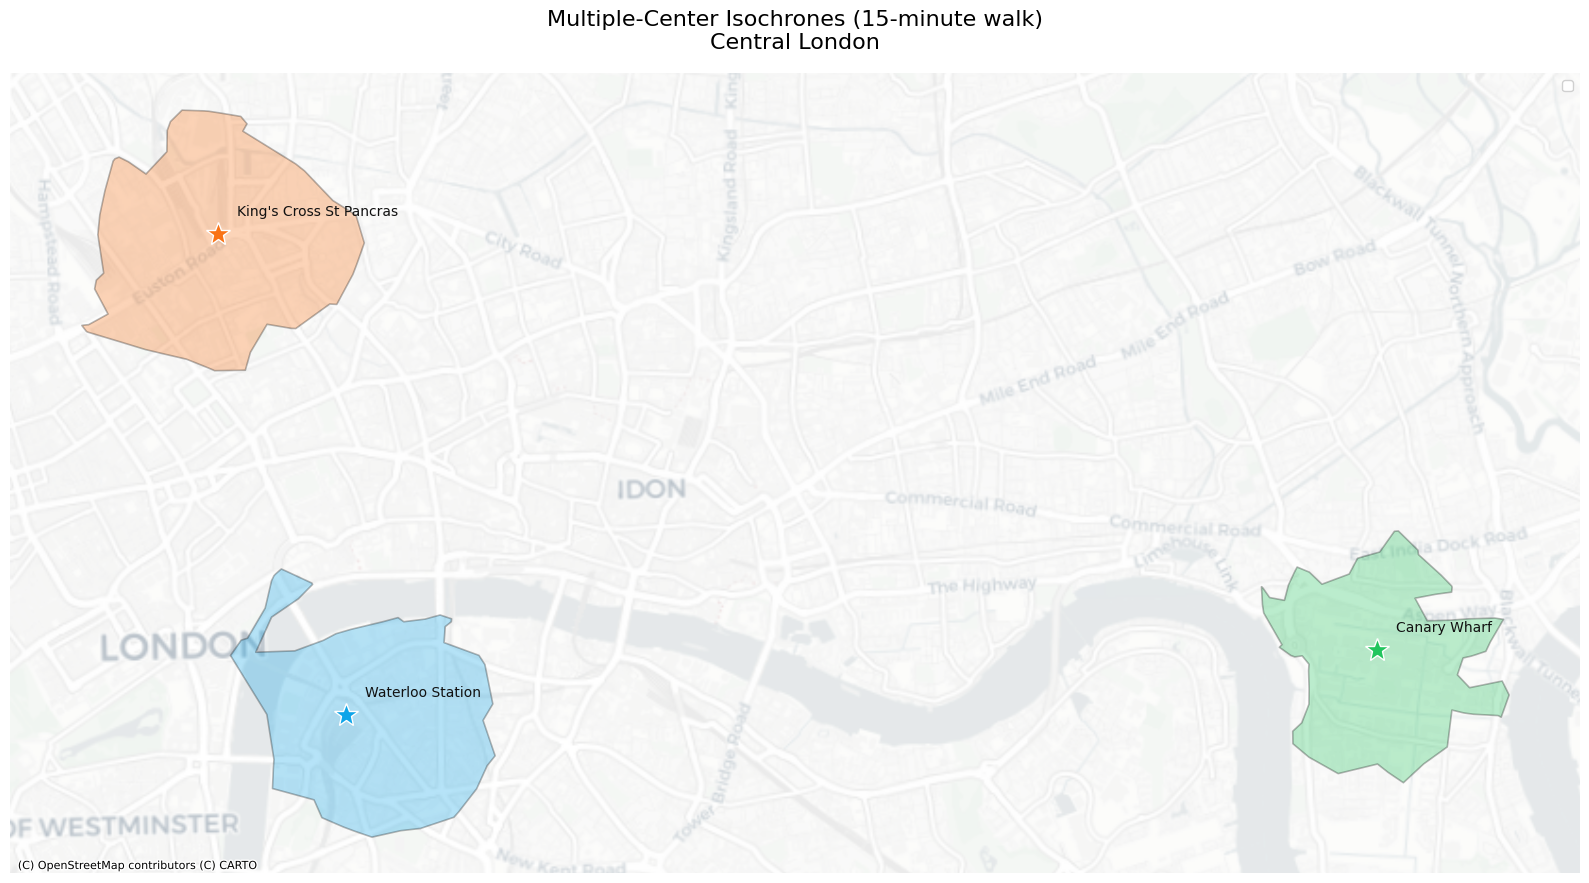

In [43]:
fig, ax = plt.subplots(figsize=(16, 14))

multi_colors = ["#f97316", "#0ea5e9", "#22c55e"]

for i, row in multi_center_isochrones.iterrows():
    row_gdf = gpd.GeoDataFrame([row], geometry="geometry", crs=multi_center_isochrones.crs)
    row_gdf.plot(
        ax=ax,
        alpha=0.30,
        color=multi_colors[i % len(multi_colors)],
        edgecolor="#111111",
        linewidth=1.2,
        label=row["center_label"],
        zorder=2,
    )

for i, (pt, label) in enumerate(zip(multi_centers, center_labels, strict=False)):
    ax.plot(
        pt.x,
        pt.y,
        marker="*",
        markersize=18,
        color=multi_colors[i % len(multi_colors)],
        markeredgecolor="white",
        markeredgewidth=1.0,
        zorder=4,
    )
    ax.text(
        pt.x + 120,
        pt.y + 120,
        label,
        fontsize=10,
        color="#111111",
        zorder=5,
    )

ctx.add_basemap(ax, crs=street_nodes.crs, source=ctx.providers.CartoDB.Positron, alpha=0.6)
ax.set_title("Multiple-Center Isochrones (15-minute walk)\nCentral London", fontsize=16, color="black", pad=18)
ax.legend(loc="upper right", framealpha=0.9)
ax.axis("off")
plt.tight_layout()
plt.show()